1. 自回归模型的数学表示

自回归模型的一般形式是：
$$y_t = c + \phi_1 y_{t-1} + \phi_2 y_{t-2} + ... + \phi_p y_{t-p} + \epsilon_t$$
- $y_t $：当前时刻 $t $的值（例如，第 5 天的温度）
- $c $：常数项
- $\phi_1, \phi_2, ..., \phi_p $：自回归系数（用来权衡前几天数据的重要性）
- $\epsilon_t $：误差项（代表模型未解释的随机波动）自回归模型的数学表示
自回归模型的一般形式是：
$$y_t = c + \phi_1 y_{t-1} + \phi_2 y_{t-2} + ... + \phi_p y_{t-p} + \epsilon_t$$
- $y_t $：当前时刻 $t $的值（例如，第 5 天的温度）
- $c $：常数项
- $\phi_1, \phi_2, ..., \phi_p $：自回归系数（用来权衡前几天数据的重要性）
- $\epsilon_t $：误差项（代表模型未解释的随机波动）

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error

plt.style.use('ggplot')
sns.set_theme(style='whitegrid', palette='muted', color_codes=True)

In [3]:
data = pd.read_csv('./Dataset/1.stock_data.csv' )
print(data.head())

       Date   Open   High    Low  Close    Volume  Name
0  1/3/2006  39.69  41.22  38.79  40.91  24232729  AABA
1  1/4/2006  41.22  41.90  40.77  40.97  20553479  AABA
2  1/5/2006  40.93  41.73  40.85  41.53  12829610  AABA
3  1/6/2006  42.88  43.57  42.80  43.21  29422828  AABA
4  1/9/2006  43.10  43.66  42.82  43.42  16268338  AABA


In [4]:
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)
data.head()

,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,39.69,41.22,38.79,40.91,24232729,AABA
2006-01-04,41.22,41.90,40.77,40.97,20553479,AABA
2006-01-05,40.93,41.73,40.85,41.53,12829610,AABA
2006-01-06,42.88,43.57,42.80,43.21,29422828,AABA
2006-01-09,43.10,43.66,42.82,43.42,16268338,AABA


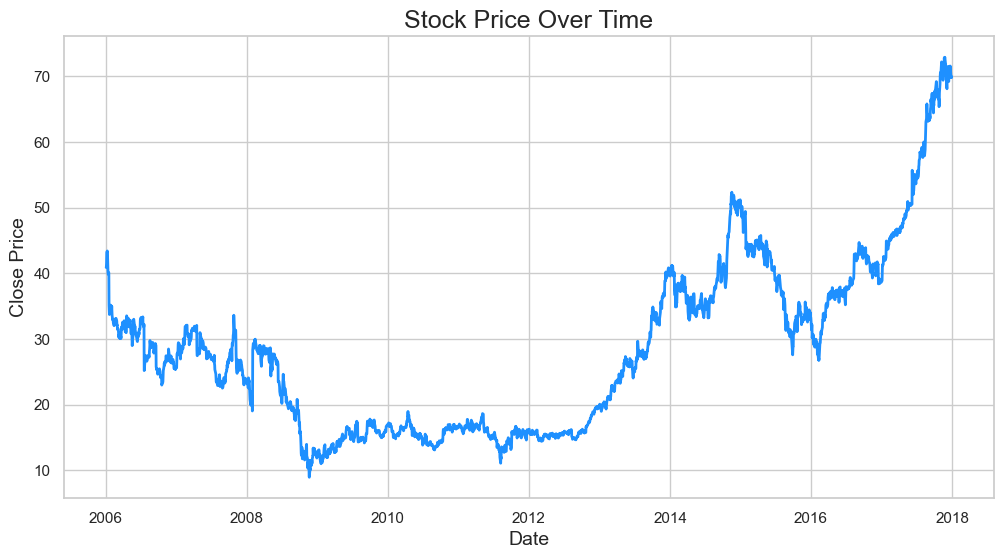

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(data['Close'], color='dodgerblue', lw=2)
plt.title('Stock Price Over Time', fontsize=18)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Close Price', fontsize=14)
plt.show()

In [8]:
train_size = np.floor(len(data) * 0.8).astype(int)
train, test = data.iloc[:train_size], data.iloc[train_size:]
print(f'Training set size: {len(train)}')

Training set size: 2415


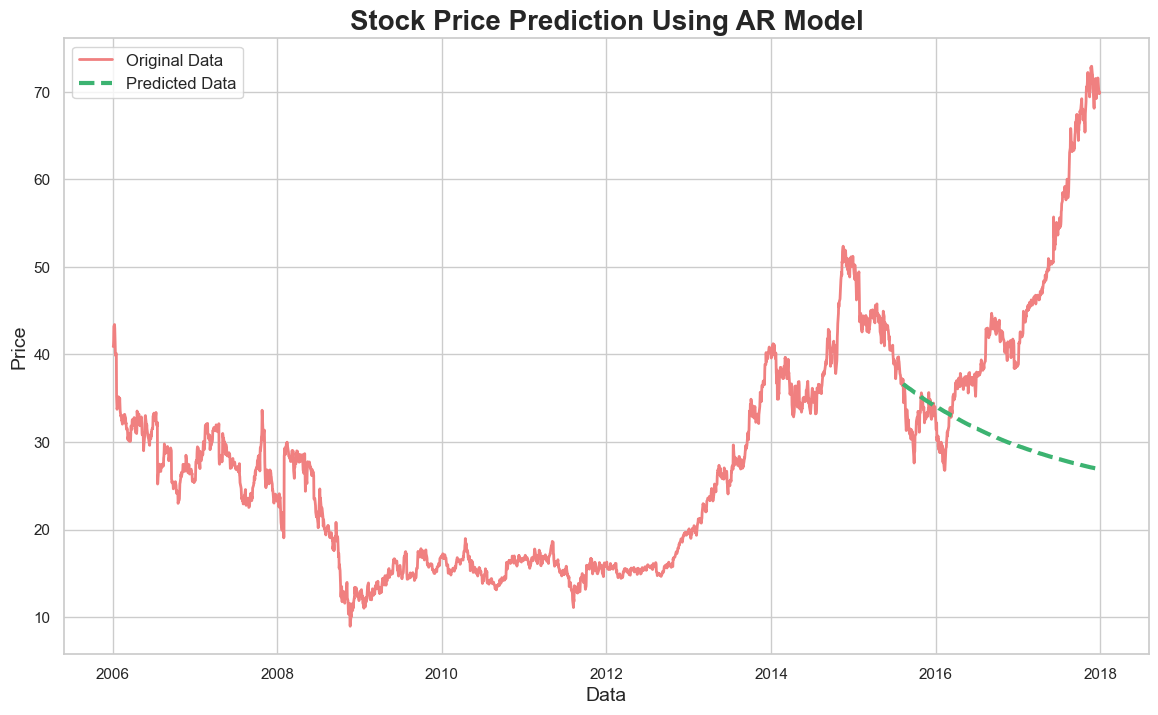

In [11]:
import warnings
warnings.filterwarnings("ignore")
model = AutoReg(train['Close'], lags=5)  # 使用5阶自回归模型
model_fit = model.fit()
predictions = model_fit.predict(start=len(train), end=len(train) + len(test) - 1, dynamic=True)
predictions.index = test.index[:len(predictions)]

plt.figure(figsize=(14, 8))
plt.plot(data.index, data['Close'], color='lightcoral', label='Original Data', lw=2)
plt.plot(test.index, predictions, color='mediumseagreen', linestyle='--', label='Predicted Data', lw=3)
plt.title('Stock Price Prediction Using AR Model', fontsize=20, fontweight='bold')
plt.xlabel('Data', fontsize=14)
plt.ylabel('Price', fontsize=14)
plt.legend(loc='best', fontsize=12)
plt.grid(True)
plt.show()

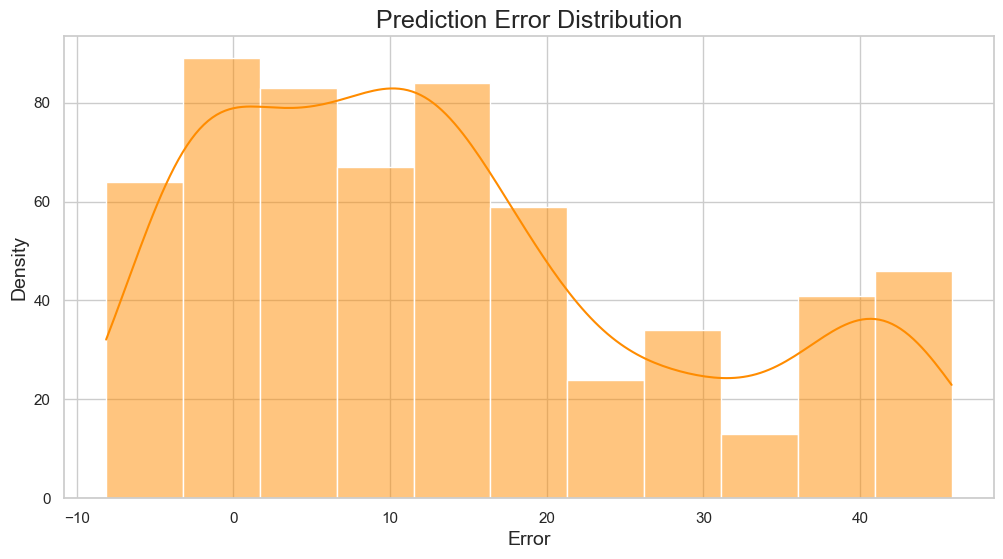

In [14]:
errors = test['Close'] - predictions[:len(test)]

plt.figure(figsize=(12, 6))
sns.histplot(errors, kde=True, color='darkorange')
plt.title('Prediction Error Distribution', fontsize=18)
plt.xlabel('Error', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.show()

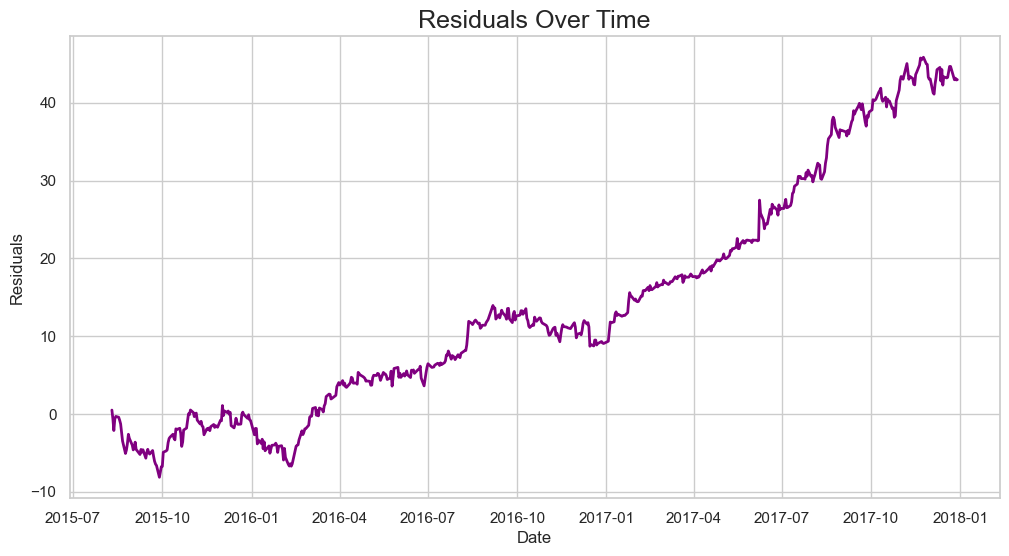

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(test.index, errors, color='purple', lw=2)
plt.title('Residuals Over Time', fontsize=18)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.grid(True)
plt.show()